<a href="https://colab.research.google.com/github/Youssef-Hamdy-Mahmoud/Auto-Cars-Sales-PROJECT1/blob/main/Clustring__DSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Import Libraries

In [35]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
import io

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

Cell 2 — Upload and Load Dataset

In [36]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset shape:", df.shape)
display(df.head())

Saving global_cancer_patients_2015_2024.csv to global_cancer_patients_2015_2024 (1).csv
Dataset shape: (9999, 15)


,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


Cell 3 — Remove ID and Target Columns for EDA

In [37]:
df_eda = df.drop(
    columns=["Patient_ID", "Target_Severity_Score"],
    errors="ignore"
)

print("Original Dataset Shape:", df.shape)
print("EDA Dataset Shape:", df_eda.shape)

display(df_eda.head())

Original Dataset Shape: (9999, 15)
EDA Dataset Shape: (9999, 13)


,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years
0,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9
1,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7
2,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1
3,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6
4,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9


Cell 4 — Basic Data Exploration

In [38]:
print("Dataset Information:")
df_eda.info()

print("\nMissing Values:")
display(df_eda.isnull().sum())

print("\nStatistical Summary:")
display(df_eda.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 9999 non-null   int64  
 1   Gender              9999 non-null   object 
 2   Country_Region      9999 non-null   object 
 3   Year                9999 non-null   int64  
 4   Genetic_Risk        9999 non-null   float64
 5   Air_Pollution       9999 non-null   float64
 6   Alcohol_Use         9999 non-null   float64
 7   Smoking             9999 non-null   float64
 8   Obesity_Level       9999 non-null   float64
 9   Cancer_Type         9999 non-null   object 
 10  Cancer_Stage        9999 non-null   object 
 11  Treatment_Cost_USD  9999 non-null   float64
 12  Survival_Years      9999 non-null   float64
dtypes: float64(7), int64(2), object(4)
memory usage: 1015.7+ KB

Missing Values:


,0
Age,0
Gender,0
Country_Region,0
Year,0
Genetic_Risk,0
Air_Pollution,0
Alcohol_Use,0
Smoking,0
Obesity_Level,0
Cancer_Type,0



Statistical Summary:


,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years
count,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,54.542454,2019.455246,5.009581,5.025853,5.043024,4.946715,4.991929,52716.162763,5.049645
std,20.189946,2.873643,2.869428,2.893883,2.890580,2.870326,2.885086,27448.430915,2.879976
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5009.200000,0.000000
25%,37.000000,2017.000000,2.600000,2.500000,2.600000,2.400000,2.500000,28775.540000,2.600000
50%,54.000000,2019.000000,5.000000,5.100000,5.000000,4.900000,5.000000,53212.710000,5.000000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76416.855000,7.500000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000


Cell 5 — Check Dataset Size

In [39]:
rows = df.shape[0]

print("Number of rows:", rows)

if 5000 <= rows <= 10000:
    print("Dataset size is valid for the assignment.")
else:
    print("Dataset size is NOT within the required range.")

Number of rows: 9999
Dataset size is valid for the assignment.


Cell 6 — Explore Categorical Columns

In [40]:
categorical_cols = df_eda.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_eda[col].value_counts())


Gender:
Gender
Male      3363
Female    3353
Other     3283
Name: count, dtype: int64

Country_Region:
Country_Region
Germany      1036
Brazil       1016
UK           1015
Australia    1011
India        1009
China         995
Russia        994
Pakistan      989
USA           973
Canada        961
Name: count, dtype: int64

Cancer_Type:
Cancer_Type
Colon       1317
Leukemia    1293
Lung        1282
Prostate    1265
Cervical    1225
Skin        1208
Breast      1207
Liver       1202
Name: count, dtype: int64

Cancer_Stage:
Cancer_Stage
Stage III    2025
Stage II     2005
Stage IV     2003
Stage I      1991
Stage 0      1975
Name: count, dtype: int64


Cell 7 — Visualize Numerical Features

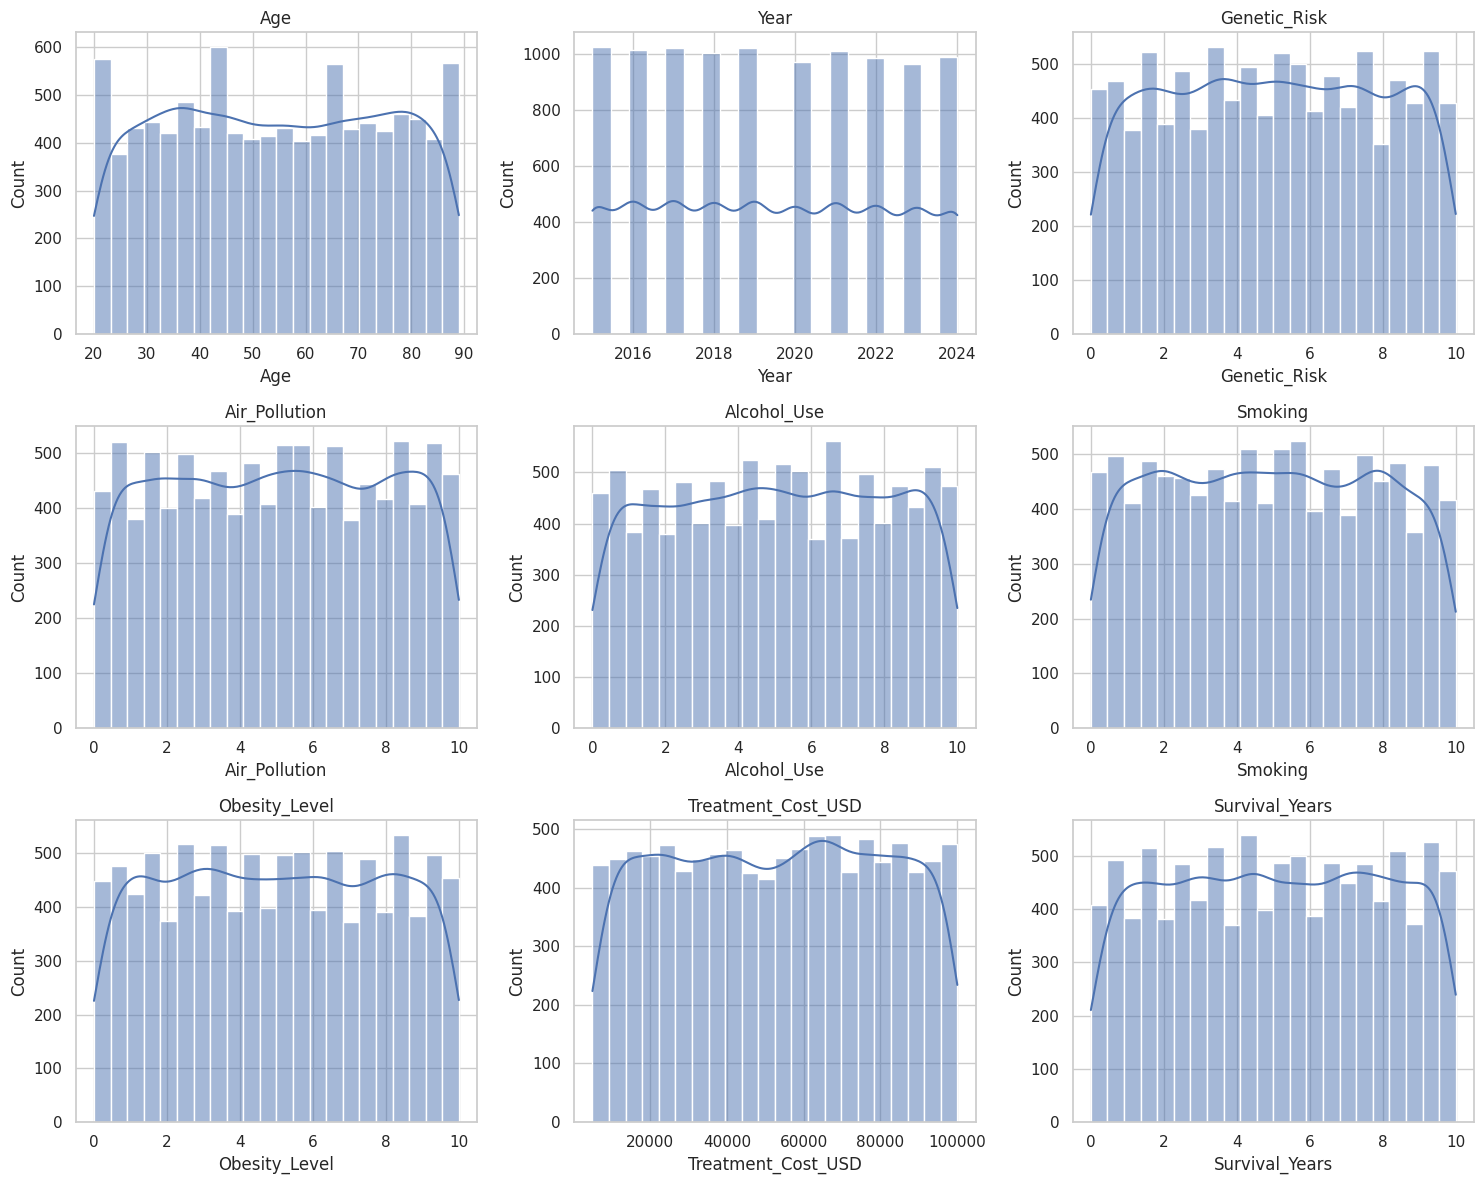

In [41]:
numeric_cols = df_eda.select_dtypes(include=["int64", "float64"]).columns

num_cols_count = len(numeric_cols)
cols_per_row = 3
rows_count = math.ceil(num_cols_count / cols_per_row)

plt.figure(figsize=(15, rows_count * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows_count, cols_per_row, i)
    sns.histplot(data=df_eda, x=col, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Cell 8 — Cancer Type Distribution

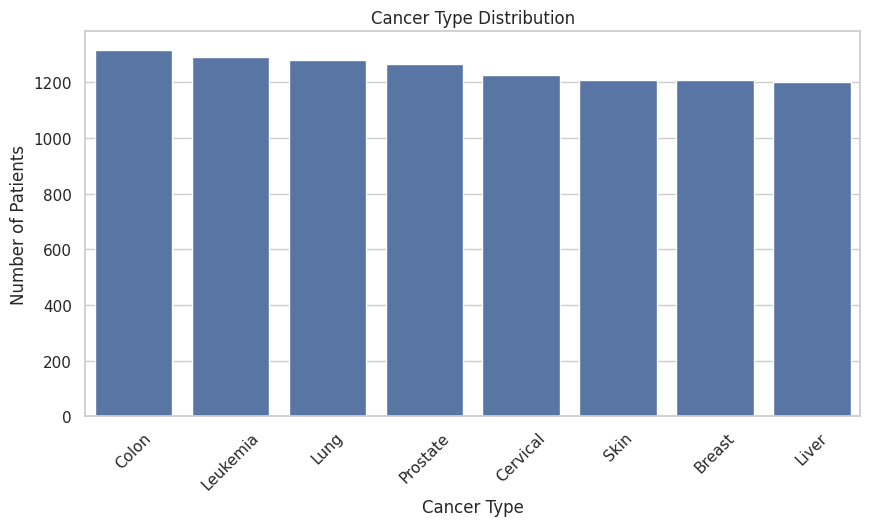

In [42]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_eda,
    x="Cancer_Type",
    order=df_eda["Cancer_Type"].value_counts().index
)

plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

Cell 9 — Cancer Stage Distribution

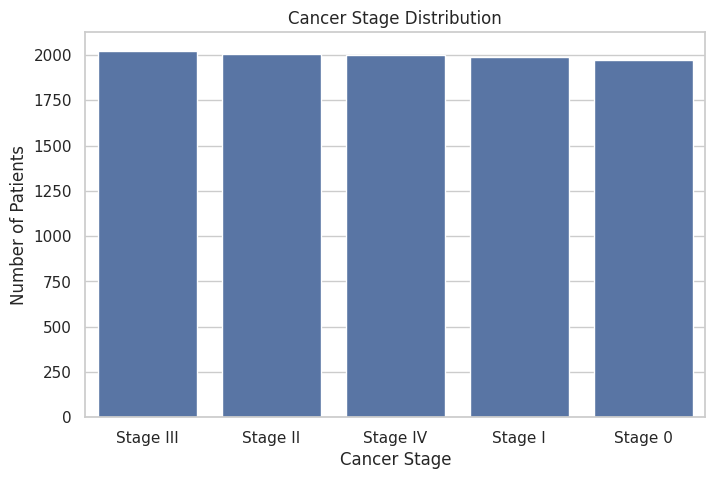

In [43]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_eda,
    x="Cancer_Stage",
    order=df_eda["Cancer_Stage"].value_counts().index
)

plt.title("Cancer Stage Distribution")
plt.xlabel("Cancer Stage")
plt.ylabel("Number of Patients")
plt.show()

Cell 10 — Correlation Heatmap

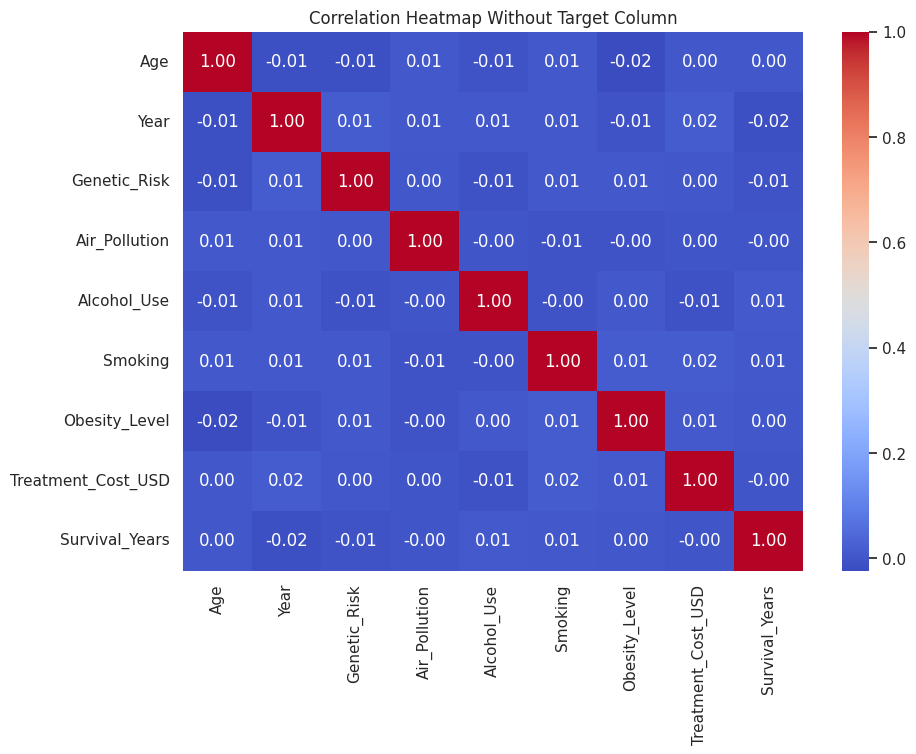

In [44]:
numeric_cols = df_eda.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(10, 7))

corr = df_eda[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap Without Target Column")
plt.show()

Cell 11 — Prepare Dataset for Clustering

In [45]:
df_cluster = df_eda.copy()

print("Clustering dataset shape:", df_cluster.shape)
display(df_cluster.head())

Clustering dataset shape: (9999, 13)


,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years
0,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9
1,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7
2,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1
3,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6
4,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9


Cell 12 — Separate Numerical and Categorical Features

In [46]:
numeric_features = df_cluster.select_dtypes(include=["int64", "float64"]).columns
categorical_features = df_cluster.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['Age', 'Year', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Treatment_Cost_USD', 'Survival_Years']

Categorical Features:
['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']


Cell 13 — Data Preprocessing

In [47]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(df_cluster)

print("Processed data shape:", X_processed.shape)

Processed data shape: (9999, 35)


Cell 14 — Apply PCA

In [48]:
X_processed_dense = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_processed_dense)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

pca_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])

display(pca_df.head())

PCA shape: (9999, 2)
Explained variance ratio: [0.08521703 0.08392304]


,PCA1,PCA2
0,0.124057,0.882356
1,-0.363949,0.526448
2,-0.933040,-2.071606
3,-0.946788,0.091656
4,0.051291,-0.783669


Cell 15 — Elbow Method for K-Means

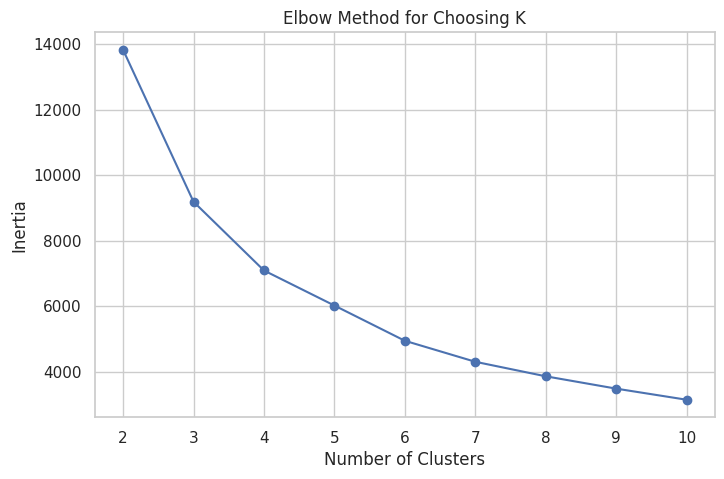

In [49]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()

Cell 16 — Silhouette Scores for K-Means

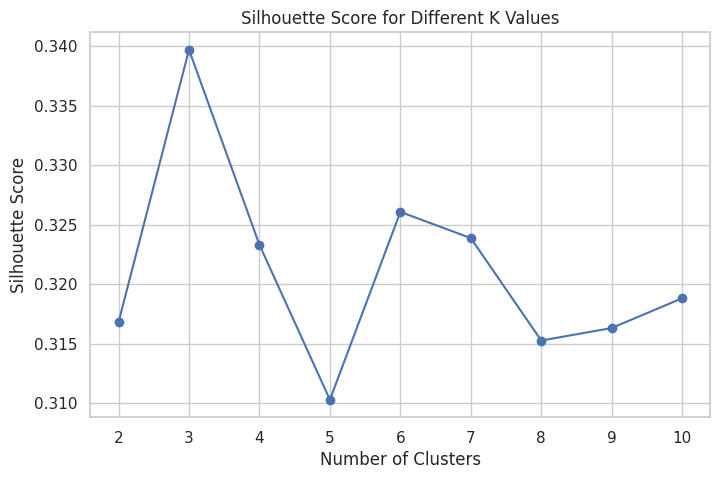

Best K based on Silhouette Score: 3


In [50]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()

best_k = list(k_values)[np.argmax(silhouette_scores)]

print("Best K based on Silhouette Score:", best_k)

Cell 17 — Algorithm 1: K-Means Clustering

In [51]:
kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X_pca)

df["KMeans_Cluster"] = kmeans_labels
pca_df["KMeans_Cluster"] = kmeans_labels

display(df[["Age", "Gender", "Cancer_Type", "Cancer_Stage", "KMeans_Cluster"]].head())

,Age,Gender,Cancer_Type,Cancer_Stage,KMeans_Cluster
0,71,Male,Lung,Stage III,1
1,34,Male,Leukemia,Stage 0,1
2,80,Male,Breast,Stage II,2
3,40,Male,Colon,Stage I,2
4,43,Female,Skin,Stage III,0


Cell 18 — Visualize K-Means Clusters

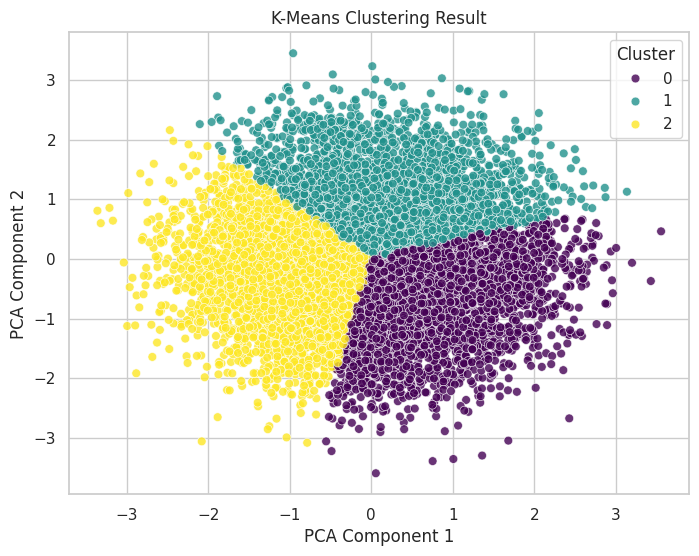

In [52]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="KMeans_Cluster",
    palette="viridis",
    s=40,
    alpha=0.8
)

plt.title("K-Means Clustering Result")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

Cell 19 — K-Means Cluster Distribution

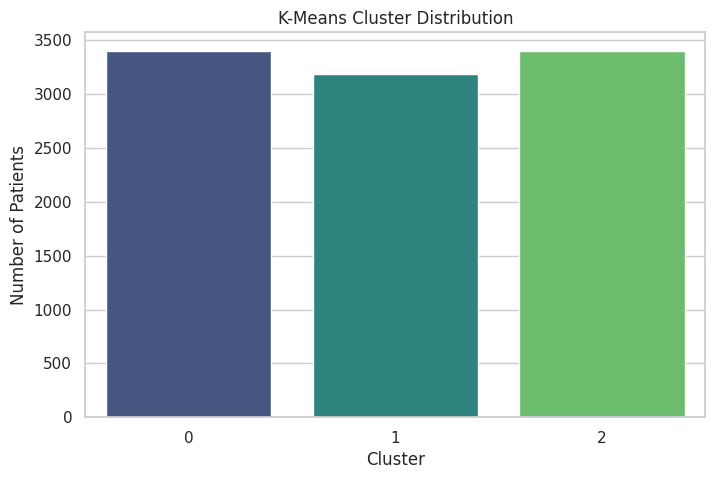

In [53]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="KMeans_Cluster",
    palette="viridis"
)

plt.title("K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Patients")
plt.show()

Cell 20 — Algorithm 2: Agglomerative Clustering

In [54]:
agg_model = AgglomerativeClustering(
    n_clusters=best_k
)

agg_labels = agg_model.fit_predict(X_pca)

df["Agglomerative_Cluster"] = agg_labels
pca_df["Agglomerative_Cluster"] = agg_labels

display(df[["Age", "Gender", "Cancer_Type", "Cancer_Stage", "Agglomerative_Cluster"]].head())

,Age,Gender,Cancer_Type,Cancer_Stage,Agglomerative_Cluster
0,71,Male,Lung,Stage III,0
1,34,Male,Leukemia,Stage 0,1
2,80,Male,Breast,Stage II,2
3,40,Male,Colon,Stage I,1
4,43,Female,Skin,Stage III,2


Cell 21 — Visualize Agglomerative Clusters

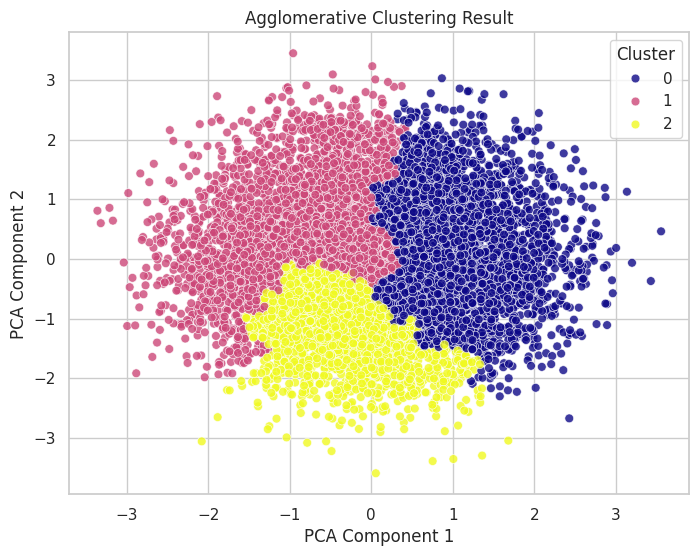

In [55]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Agglomerative_Cluster",
    palette="plasma",
    s=40,
    alpha=0.8
)

plt.title("Agglomerative Clustering Result")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

Cell 22 — Agglomerative Cluster Distribution

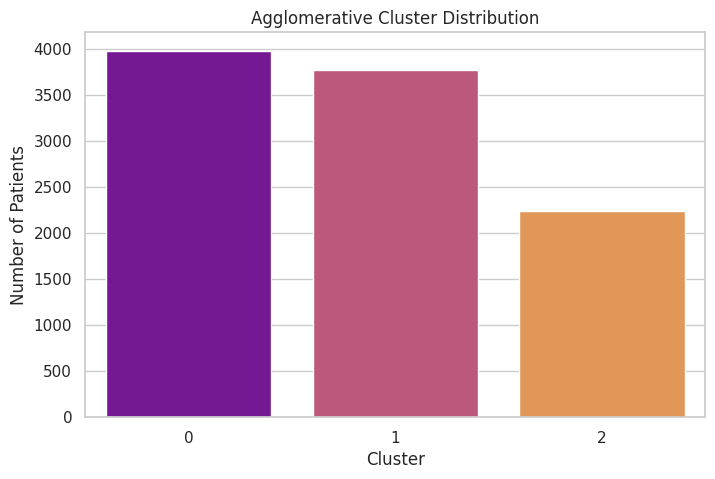

In [56]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Agglomerative_Cluster",
    palette="plasma"
)

plt.title("Agglomerative Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Patients")
plt.show()

Cell 23 — Evaluate Both Algorithms

In [57]:
def evaluate_clustering(X, labels, algorithm_name):
    silhouette = silhouette_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)

    return {
        "Algorithm": algorithm_name,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Score": davies,
        "Calinski-Harabasz Score": calinski
    }

results = []

results.append(evaluate_clustering(X_pca, kmeans_labels, "K-Means"))
results.append(evaluate_clustering(X_pca, agg_labels, "Agglomerative Clustering"))

results_df = pd.DataFrame(results)

display(results_df)

,Algorithm,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,K-Means,0.339687,0.921407,6266.305931
1,Agglomerative Clustering,0.279259,1.033199,4956.869751


Cell 24 — Silhouette Score Comparison

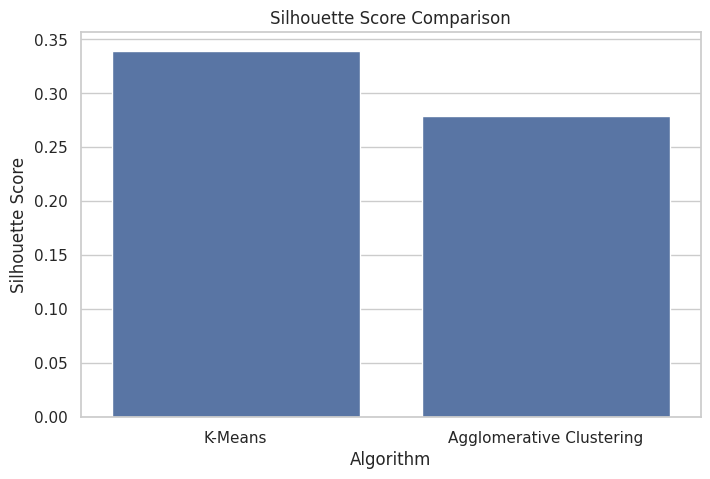

In [58]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Algorithm",
    y="Silhouette Score"
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")
plt.show()

Cell 25 — Davies-Bouldin Score Comparison

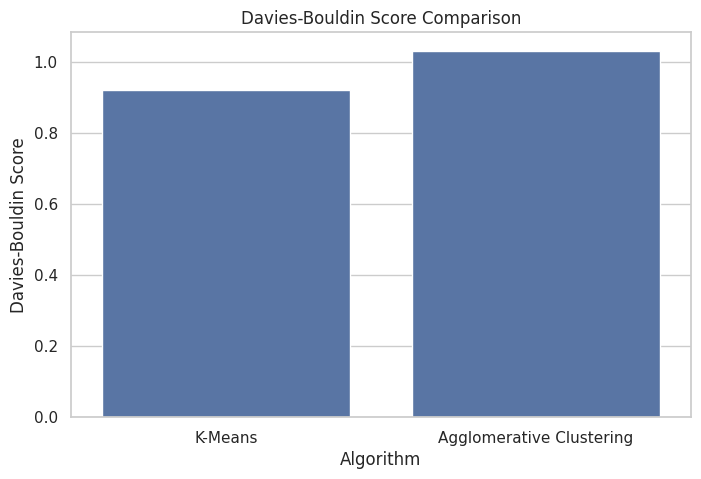

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Algorithm",
    y="Davies-Bouldin Score"
)

plt.title("Davies-Bouldin Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Davies-Bouldin Score")
plt.show()

Cell 26 — Calinski-Harabasz Score Comparison

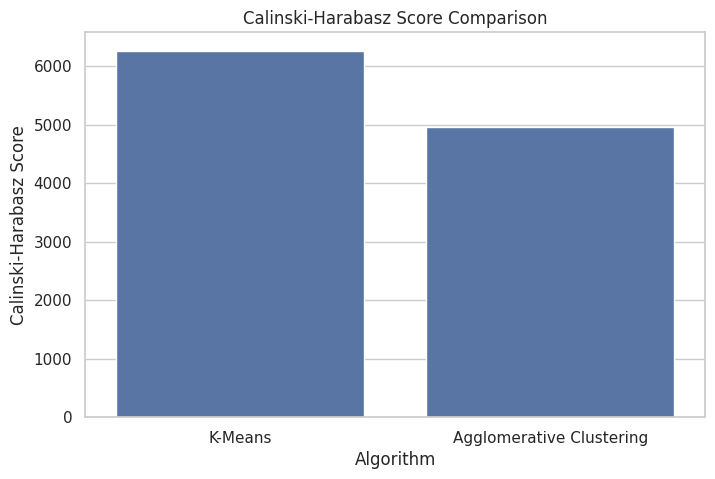

In [60]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Algorithm",
    y="Calinski-Harabasz Score"
)

plt.title("Calinski-Harabasz Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Calinski-Harabasz Score")
plt.show()

Cell 28 — Save Final Dataset

In [61]:
df.to_csv("cancer_clustering_results.csv", index=False)

print("File saved successfully: cancer_clustering_results.csv")

File saved successfully: cancer_clustering_results.csv
